In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import gudhi as gd
from gudhi.representations import Landscape
import matplotlib.animation as animation
from IPython.display import HTML



In [2]:
# Import data
snow_data = pd.read_csv("./timeseries/montana_snow_timeseries.csv",index_col = 0)
temp_data = pd.read_csv("./timeseries/montana_TMAX_timeseries.csv",index_col = 0).reset_index()
temp_data['DATE'] = pd.to_datetime(temp_data['DATE'])

polar_wind = pd.read_csv("./timeseries/polar_vortex_timeseries.csv",index_col = 0).reset_index()

In [3]:
# Parameters for Takens' embedding and sliding window
embedding_dim = 3  # Embedding dimension (m)
time_delay = 7    # Time delay (tau)
window_size = 30   # Sliding window size
max_dimension = 1  # Max dimension for persistence computation (usually 1 for loops)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

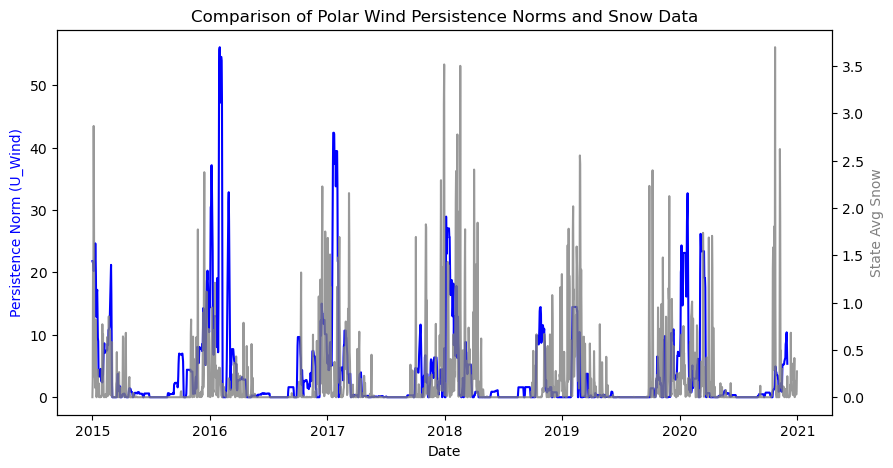

In [4]:
variable_for_comparison = snow_data
variable_for_comparison_name = "Snow Data"
df = polar_wind

# Convert Date columns to datetime
variable_for_comparison['DATE'] = pd.to_datetime(variable_for_comparison['DATE'], format='%m/%d/%Y')
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2015 to 2020
df_filtered = df[(df['Date'] >= '2015-01-01') & (df['Date'] <= '2020-12-31')]
variable_for_comparison_filtered = variable_for_comparison[(variable_for_comparison['DATE'] >= '2015-01-01') & (variable_for_comparison['DATE'] <= '2020-12-31')]

# Ensure data is indexed by date
df_filtered = df_filtered.set_index('Date')
data1 = df_filtered['U_Wind']

# Initialize an array to store the persistence diagrams
dgms = np.empty(len(data1) - window_size, dtype=object)

# Sliding window with Takens' embedding
for i in range(len(data1) - window_size):
    window = data1[i:i + window_size].values  # Get a window of daily values
    X = np.zeros((window_size - time_delay, time_delay), dtype=float)  # Prepare array for embedding

    # Takens' embedding: Create embedded vectors
    for j in range(window_size - time_delay):
        X[j, :] = window[j:j + time_delay]

    # Compute Rips Complex and persistence diagram
    rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
    rc.persistence()
    dgm = rc.persistence_intervals_in_dimension(1)  # Extract persistence diagram for dimension 1 (loops)
    dgms[i] = dgm

# Compute the norms of the landscapes
norms = np.zeros(dgms.shape[0])  # Array to store norms of the landscapes
for i in range(dgms.shape[0]):
    l = Landscape(num_landscapes=2, resolution=10).fit_transform([dgms[i]])
    norms[i] = np.linalg.norm(l[0])  # Compute the norm of the first landscape

# Align the snow data
variable_for_comparison_aligned = variable_for_comparison_filtered[variable_for_comparison_filtered['DATE'].isin(data1.index)]

# Plot persistence norms and snow data
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(data1.index[:len(norms)], norms, color='blue', label='Persistence Norm of U_Wind')
ax2.plot(variable_for_comparison_aligned['DATE'], variable_for_comparison_aligned.iloc[:,1], color='gray', label='State Avg Snow', alpha=0.8)

# Labels and title
ax1.set_xlabel('Date')
ax1.set_ylabel('Persistence Norm (U_Wind)', color='blue')
ax2.set_ylabel('State Avg Snow', color='gray')
plt.title(f'Comparison of Polar Wind Persistence Norms and {variable_for_comparison_name}')

# Show plot
plt.show()

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

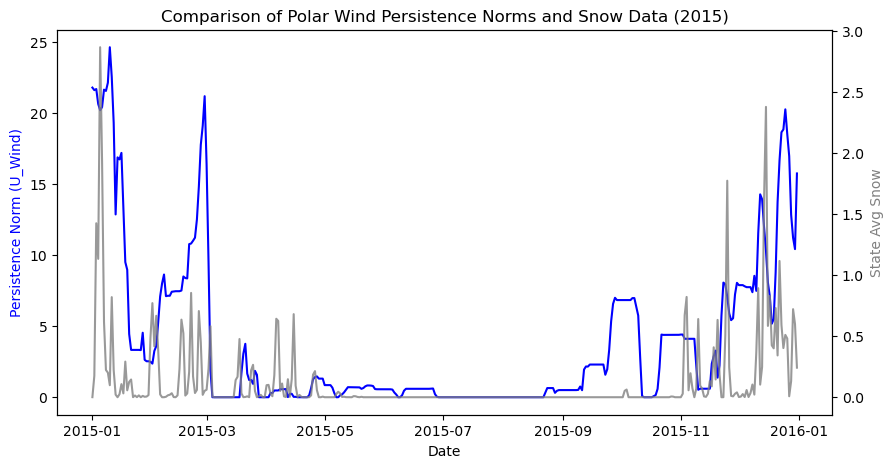

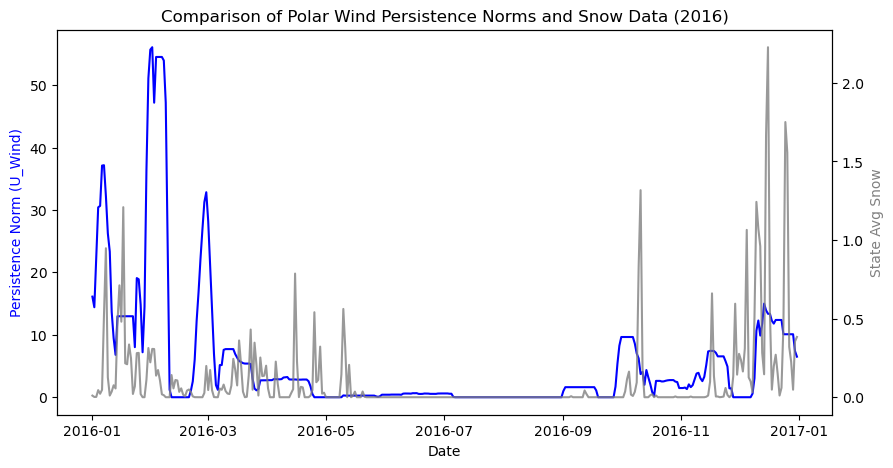

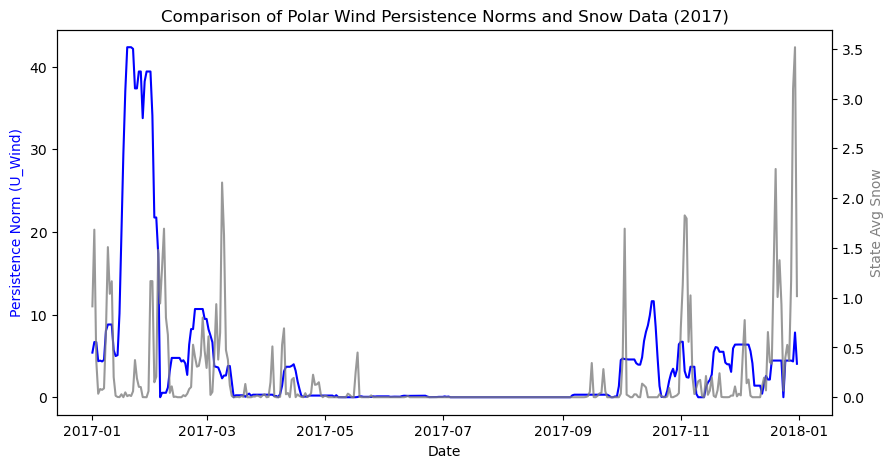

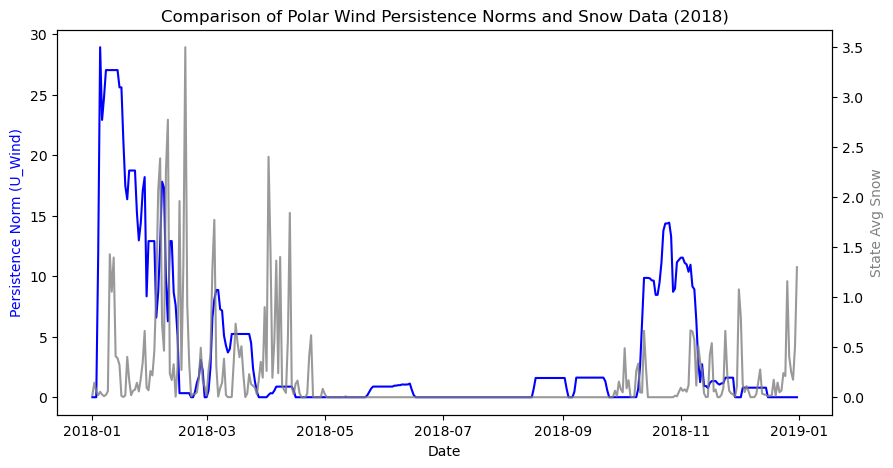

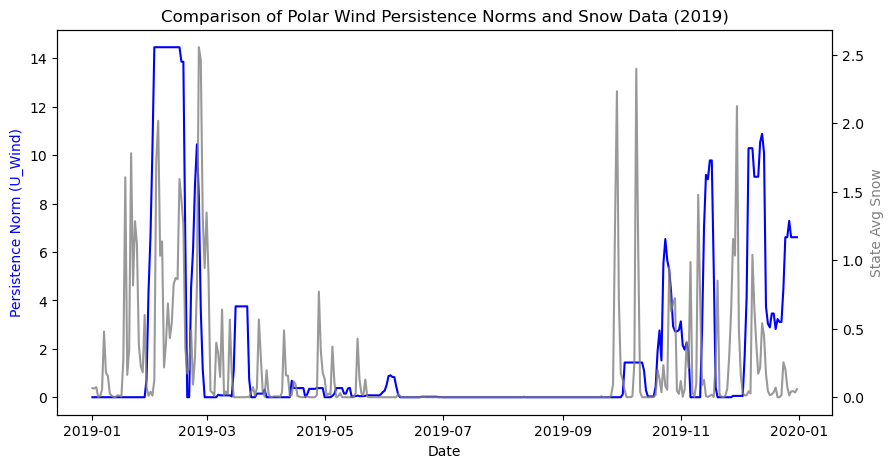

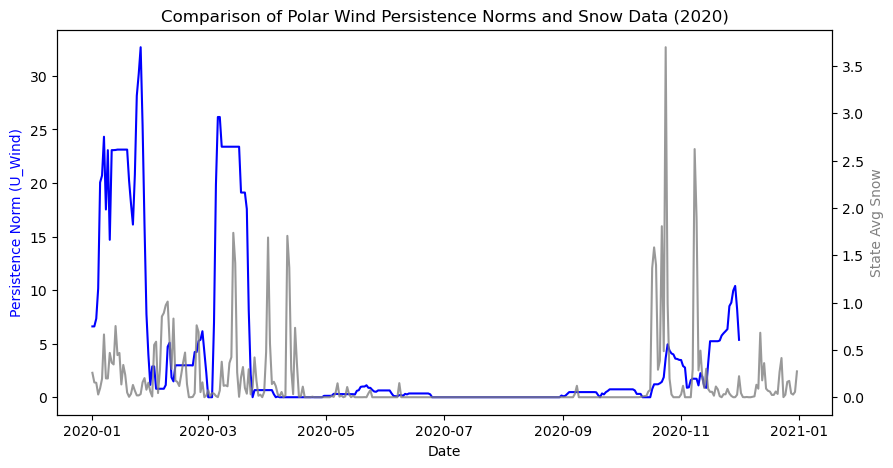

In [5]:
variable_for_comparison = snow_data
variable_for_comparison_name = "Snow Data"
df = polar_wind

# Convert Date columns to datetime
variable_for_comparison['DATE'] = pd.to_datetime(variable_for_comparison['DATE'], format='%m/%d/%Y')
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2015 to 2020
df_filtered = df[(df['Date'] >= '2015-01-01') & (df['Date'] <= '2020-12-31')]
variable_for_comparison_filtered = variable_for_comparison[(variable_for_comparison['DATE'] >= '2015-01-01') & (variable_for_comparison['DATE'] <= '2020-12-31')]

# Ensure data is indexed by date
df_filtered = df_filtered.set_index('Date')
data1 = df_filtered['U_Wind']

# Initialize an array to store the persistence diagrams
dgms = np.empty(len(data1) - window_size, dtype=object)

# Sliding window with Takens' embedding
for i in range(len(data1) - window_size):
    window = data1[i:i + window_size].values  # Get a window of daily values
    X = np.zeros((window_size - time_delay, time_delay), dtype=float)  # Prepare array for embedding

    # Takens' embedding: Create embedded vectors
    for j in range(window_size - time_delay):
        X[j, :] = window[j:j + time_delay]

    # Compute Rips Complex and persistence diagram
    rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
    rc.persistence()
    dgm = rc.persistence_intervals_in_dimension(1)  # Extract persistence diagram for dimension 1 (loops)
    dgms[i] = dgm

# Compute the norms of the landscapes
norms = np.zeros(dgms.shape[0])  # Array to store norms of the landscapes
for i in range(dgms.shape[0]):
    l = Landscape(num_landscapes=2, resolution=10).fit_transform([dgms[i]])
    norms[i] = np.linalg.norm(l[0])  # Compute the norm of the first landscape

# Align the snow data
variable_for_comparison_aligned = variable_for_comparison_filtered[variable_for_comparison_filtered['DATE'].isin(data1.index)]

# Ensure indexing aligns correctly
data1_trimmed = data1.iloc[:len(norms)]  # Trim data1 to match norms length

# Generate separate plots for each year
for year in range(2015, 2021):
    start_date, end_date = f'{year}-01-01', f'{year}-12-31'
    mask = (data1_trimmed.index >= start_date) & (data1_trimmed.index <= end_date)
    snow_mask = (variable_for_comparison_aligned['DATE'] >= start_date) & (variable_for_comparison_aligned['DATE'] <= end_date)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    
    ax1.plot(data1_trimmed.index[mask], norms[mask], color='blue', label='Persistence Norm of U_Wind')
    ax2.plot(variable_for_comparison_aligned.loc[snow_mask, 'DATE'], 
             variable_for_comparison_aligned.loc[snow_mask].iloc[:, 1], 
             color='gray', label='State Avg Snow', alpha=0.8)
    
    # Labels and title
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Persistence Norm (U_Wind)', color='blue')
    ax2.set_ylabel('State Avg Snow', color='gray')
    plt.title(f'Comparison of Polar Wind Persistence Norms and {variable_for_comparison_name} ({year})')
    
    # Show plot
    plt.show()


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

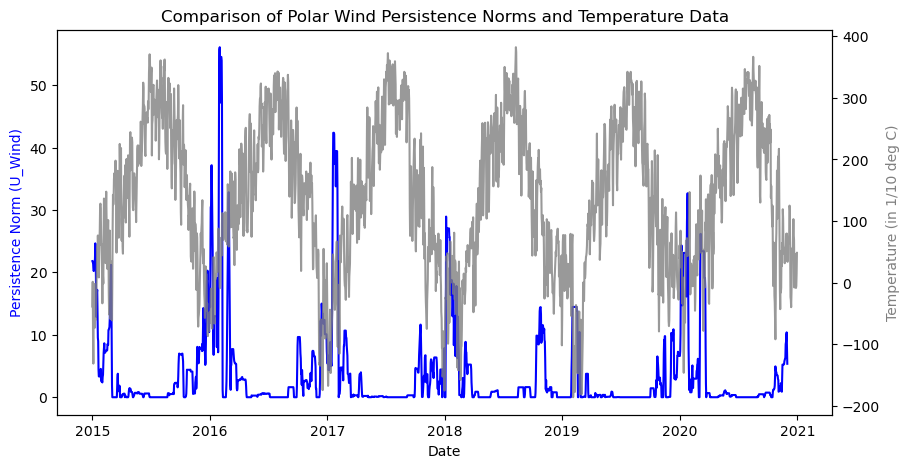

In [6]:
variable_for_comparison = temp_data
variable_for_comparison_name = "Temperature Data"
df = polar_wind

# Convert Date columns to datetime
variable_for_comparison['DATE'] = pd.to_datetime(variable_for_comparison['DATE'], format='%m/%d/%Y')
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2015 to 2020
df_filtered = df[(df['Date'] >= '2015-01-01') & (df['Date'] <= '2020-12-31')]
variable_for_comparison_filtered = variable_for_comparison[(variable_for_comparison['DATE'] >= '2015-01-01') & (variable_for_comparison['DATE'] <= '2020-12-31')]

# Ensure data is indexed by date
df_filtered = df_filtered.set_index('Date')
data1 = df_filtered['U_Wind']

# Initialize an array to store the persistence diagrams
dgms = np.empty(len(data1) - window_size, dtype=object)

# Sliding window with Takens' embedding
for i in range(len(data1) - window_size):
    window = data1[i:i + window_size].values  # Get a window of daily values
    X = np.zeros((window_size - time_delay, time_delay), dtype=float)  # Prepare array for embedding

    # Takens' embedding: Create embedded vectors
    for j in range(window_size - time_delay):
        X[j, :] = window[j:j + time_delay]

    # Compute Rips Complex and persistence diagram
    rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
    rc.persistence()
    dgm = rc.persistence_intervals_in_dimension(1)  # Extract persistence diagram for dimension 1 (loops)
    dgms[i] = dgm

# Compute the norms of the landscapes
norms = np.zeros(dgms.shape[0])  # Array to store norms of the landscapes
for i in range(dgms.shape[0]):
    l = Landscape(num_landscapes=2, resolution=10).fit_transform([dgms[i]])
    norms[i] = np.linalg.norm(l[0])  # Compute the norm of the first landscape

# Align the snow data
variable_for_comparison_aligned = variable_for_comparison_filtered[variable_for_comparison_filtered['DATE'].isin(data1.index)]

# Plot persistence norms and snow data
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(data1.index[:len(norms)], norms, color='blue', label='Persistence Norm of U_Wind')
ax2.plot(variable_for_comparison_aligned['DATE'], variable_for_comparison_aligned.iloc[:,1], color='gray', label=variable_for_comparison_name, alpha=0.8)

# Labels and title
ax1.set_xlabel('Date')
ax1.set_ylabel('Persistence Norm (U_Wind)', color='blue')
ax2.set_ylabel('Temperature (in 1/10 deg C)', color='gray')
plt.title(f'Comparison of Polar Wind Persistence Norms and {variable_for_comparison_name}')

# Show plot
plt.show()

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

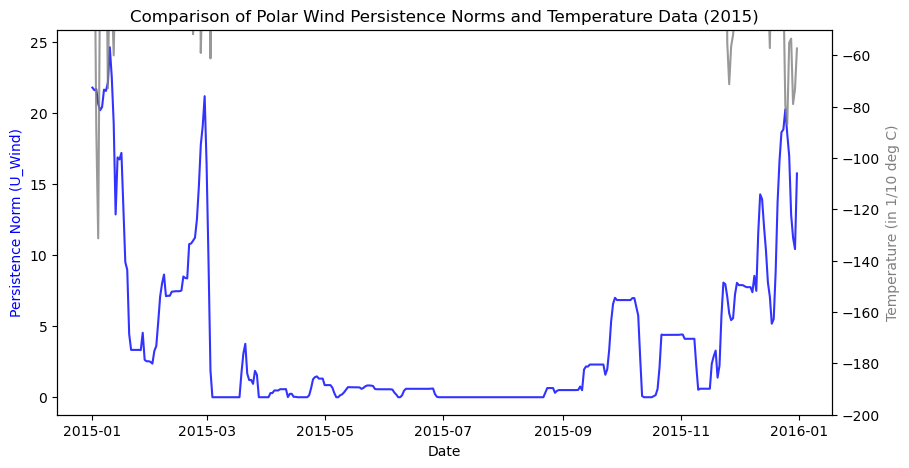

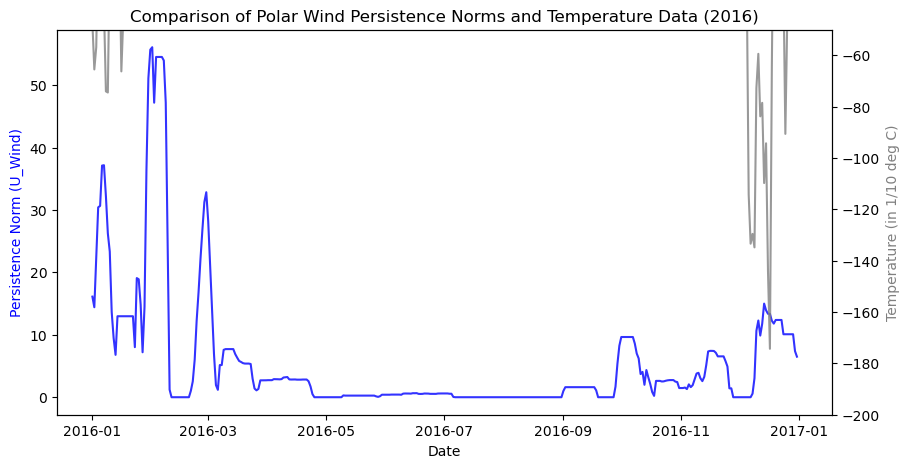

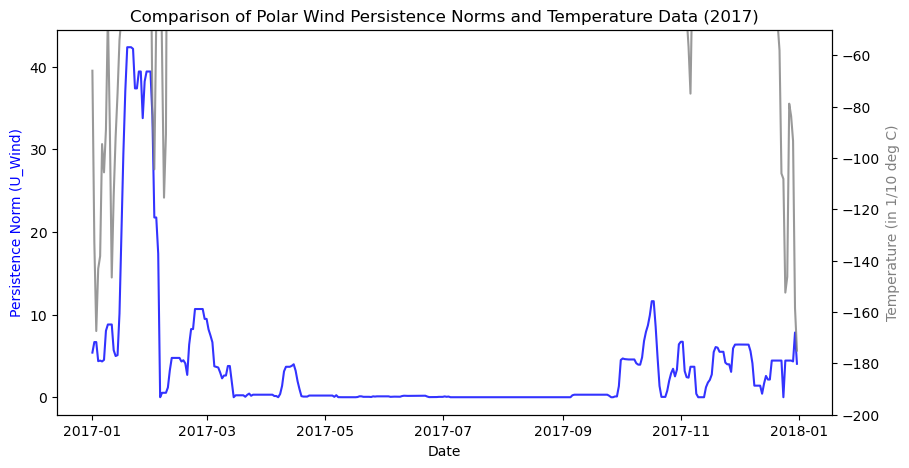

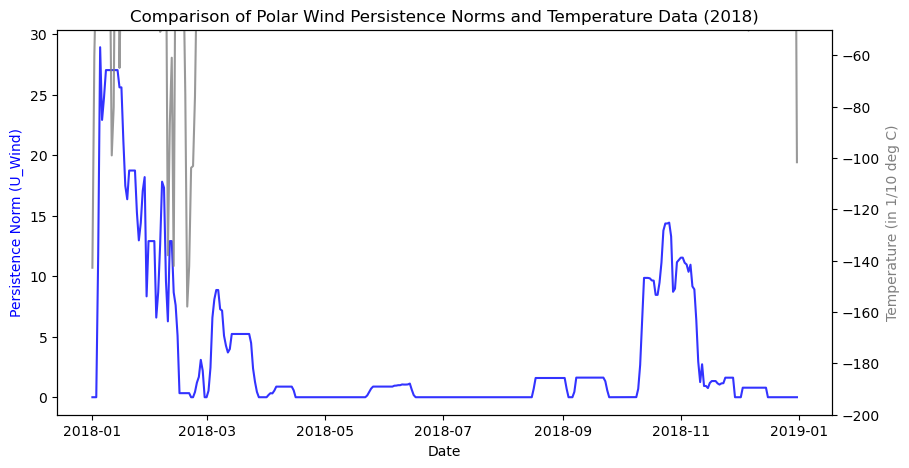

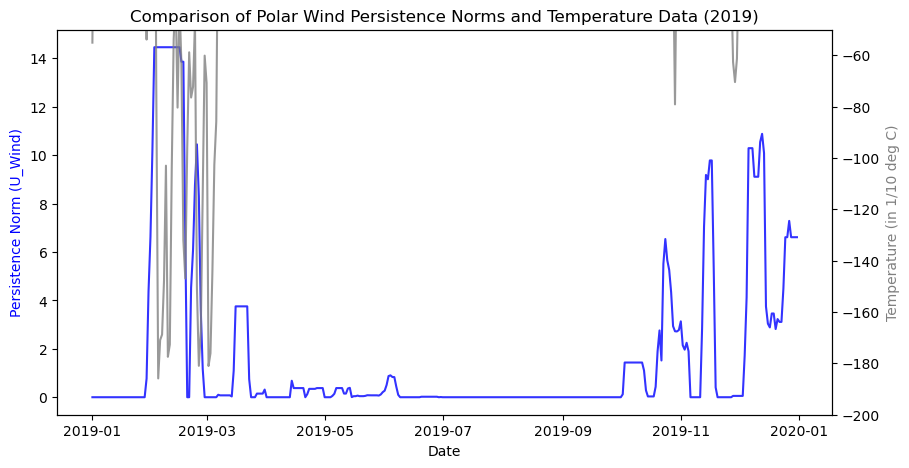

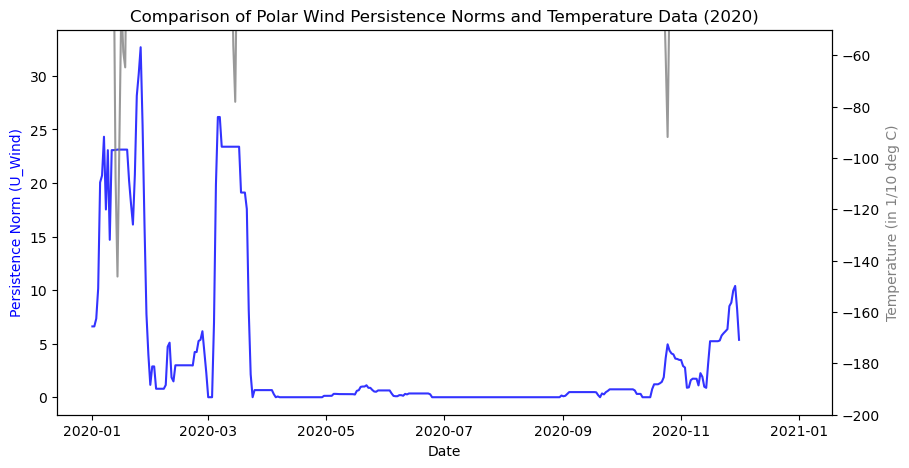

In [7]:
variable_for_comparison = temp_data
variable_for_comparison_name = "Temperature Data"
df = polar_wind

# Convert Date columns to datetime
variable_for_comparison['DATE'] = pd.to_datetime(variable_for_comparison['DATE'], format='%m/%d/%Y')
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2015 to 2020
df_filtered = df[(df['Date'] >= '2015-01-01') & (df['Date'] <= '2020-12-31')]
variable_for_comparison_filtered = variable_for_comparison[(variable_for_comparison['DATE'] >= '2015-01-01') & (variable_for_comparison['DATE'] <= '2020-12-31')]

# Ensure data is indexed by date
df_filtered = df_filtered.set_index('Date')
data1 = df_filtered['U_Wind']

# Initialize an array to store the persistence diagrams
dgms = np.empty(len(data1) - window_size, dtype=object)

# Sliding window with Takens' embedding
for i in range(len(data1) - window_size):
    window = data1[i:i + window_size].values  # Get a window of daily values
    X = np.zeros((window_size - time_delay, time_delay), dtype=float)  # Prepare array for embedding

    # Takens' embedding: Create embedded vectors
    for j in range(window_size - time_delay):
        X[j, :] = window[j:j + time_delay]

    # Compute Rips Complex and persistence diagram
    rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
    rc.persistence()
    dgm = rc.persistence_intervals_in_dimension(1)  # Extract persistence diagram for dimension 1 (loops)
    dgms[i] = dgm

# Compute the norms of the landscapes
norms = np.zeros(dgms.shape[0])  # Array to store norms of the landscapes
for i in range(dgms.shape[0]):
    l = Landscape(num_landscapes=2, resolution=10).fit_transform([dgms[i]])
    norms[i] = np.linalg.norm(l[0])  # Compute the norm of the first landscape

# Align the snow data
variable_for_comparison_aligned = variable_for_comparison_filtered[variable_for_comparison_filtered['DATE'].isin(data1.index)]

# Ensure indexing aligns correctly
data1_trimmed = data1.iloc[:len(norms)]  # Trim data1 to match norms length

# Generate separate plots for each year
for year in range(2015, 2021):
    start_date, end_date = f'{year}-01-01', f'{year}-12-31'
    mask = (data1_trimmed.index >= start_date) & (data1_trimmed.index <= end_date)
    snow_mask = (variable_for_comparison_aligned['DATE'] >= start_date) & (variable_for_comparison_aligned['DATE'] <= end_date)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    
    ax1.plot(data1_trimmed.index[mask], norms[mask], color='blue', label='Persistence Norm of U_Wind',alpha=0.8)
    ax2.plot(variable_for_comparison_aligned.loc[snow_mask, 'DATE'], 
             variable_for_comparison_aligned.loc[snow_mask].iloc[:, 1], 
             color='gray', label='Temperature (in 1/10 deg C)', alpha=0.8)
    
    # Labels and title
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Persistence Norm (U_Wind)', color='blue')
    ax2.set_ylabel('Temperature (in 1/10 deg C)', color='gray')
    ax2.set_ylim(-200,-50)
    plt.title(f'Comparison of Polar Wind Persistence Norms and {variable_for_comparison_name} ({year})')
    
    # Show plot
    plt.show()


In [8]:
%matplotlib notebook

# Load and preprocess data
df = polar_wind
years = [2015,2016,2017,2018,2019,2020]

for year in years:
    df['Date'] = pd.to_datetime(df['Date'])
    df_filtered = df[(df['Date'] >= f'{year}-01-01') & (df['Date'] <= f'{year}-12-31')]
    df_filtered = df_filtered.set_index('Date')
    data1 = df_filtered['U_Wind']

    # Compute persistence diagrams
    num_windows = len(data1) - window_size
    dgms = []

    def compute_persistence(window):
        X = np.zeros((window_size - time_delay, time_delay), dtype=float)
        for j in range(window_size - time_delay):
            X[j, :] = window[j:j + time_delay]
        rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
        rc.persistence()
        return rc.persistence_intervals_in_dimension(1)

    # Compute persistence diagrams for each window
    for i in range(num_windows):
        window = data1[i:i + window_size].values
        dgm = compute_persistence(window)
        dgms.append((i, dgm))  # Append all diagrams (empty or non-empty)

    # Find the maximum death value across all diagrams
    max_death = 0
    for _, dgm in dgms:
        if len(dgm) > 0:
            max_death = max(max_death, max(dgm, key=lambda x: x[1])[1])  # max death value


    # Set up figure and axis for the animation
    fig, ax = plt.subplots(figsize=(6, 6))

    # Function to compute persistence and update the plot
    def update_plot(i):
        ax.clear()  # Clear the previous plot
        
        # Get the persistence diagram for window i
        _, dgm = dgms[i]  # Access all diagrams, including empty ones
        window_start_date = df_filtered.index[i].strftime('%Y-%m-%d')  # Get the start date of the window
        
        # Always plot the diagonal line (y = x)
        ax.plot([0, max_death * 1.1], [0, max_death * 1.1], 'k--')  # Diagonal line
        
        if len(dgm) > 0:  # Only plot non-empty diagrams
            birth, death = zip(*dgm)
            ax.scatter(birth, death, color='blue')
        else:  # Empty diagram frame, plot red dot
            ax.plot(0, 0, 'ro')  # Plot a red dot for empty diagrams
        
        # Set static axis limits for all frames
        ax.set_xlim(0, max_death * 1.1)
        ax.set_ylim(0, max_death * 1.1)
        
        ax.set_xlabel('Birth')
        ax.set_ylabel('Death')
        ax.set_title(f'Window starting with {window_start_date}')

    # Create the animation
    ani = animation.FuncAnimation(fig, update_plot, frames=num_windows, interval=500, repeat=False)

    # Display the animation as a JSHTML object for Jupyter notebook
    from IPython.display import HTML
    HTML(ani.to_jshtml())

    gif_writer = animation.PillowWriter(fps=8)  # Save as GIF
    ani.save(f"persistence_diagram_{year}.gif", writer=gif_writer)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>